# Turkish Movie Review Sentiment Analysis

This project investigates sentiment classification on a Turkish movie review dataset using three different transformer architectures: encoder-only, decoder-only, and encoder-decoder models. The main objective is to compare how different language model architectures perform on binary sentiment classification. The project covers dataset preparation, exploratory data analysis, preprocessing, model fine-tuning, hyperparameter experimentation, and performance evaluation.

The following models are evaluated:

- BERTurk as the encoder-only model
- Turkish GPT-2 as the decoder-only model
- mT5-small as the encoder-decoder model

Each model is trained using multiple hyperparameter configurations. Their performances are compared using macro F1-score and accuracy on a separate test set.

## 1. Dataset Preparation and Exploratory Data Analysis

The dataset contains Turkish movie reviews labeled as either positive or negative. Positive and negative reviews are loaded from separate files and combined into a single structured dataset. Before model training, the dataset is examined to understand its overall structure and quality. The exploratory analysis includes:

- Class distribution of positive and negative reviews
- Review-length distributions
- Identification of duplicate or missing samples
- Most frequently occurring words in each sentiment class
- Comparison of text-length characteristics between positive and negative reviews

This analysis helps identify potential data-quality issues and provides insight into the linguistic characteristics of the dataset.



Dataset Overview:
Zip file: Turkish_Movie_Sentiment.zip
Total samples: 10660
Positive reviews: 5330
Negative reviews: 5330
Class balance: 50.0% / 50.0%


,text,label,label_str
0,gerçekten harika bir yapim birçok kez izledim ...,1,positive
1,her izledigimde hayranlik duydugum gerçek klas...,1,positive
2,gerçekten tarihi savas filmleri arasinda tarti...,1,positive
3,aldigi ödülleri sonuna dek hak eden muhtesem b...,1,positive
4,özgürlük denilince aklima gelen ilk film.bir b...,1,positive




Length Statistic:

Overall statistics:


,count,mean,std,min,25%,50%,75%,90%,95%,max
char_len,10660.0,139.679644,73.394387,1.0,80.0,132.0,194.0,249.0,272.0,299.0
word_len,10660.0,19.474390,10.244016,1.0,11.0,18.0,27.0,34.0,38.0,50.0



Statistics by label:


char_len                                                 word_len  \
             count    mean    std  min    50%    90%    95%    max    count   
label_str                                                                     
negative    5330.0  140.74  74.62  1.0  132.0  252.0  275.0  299.0   5330.0   
positive    5330.0  138.62  72.14  1.0  131.0  245.0  269.0  299.0   5330.0   

                                                      
            mean    std  min   50%   90%   95%   max  
label_str                                             
negative   19.91  10.52  1.0  19.0  35.0  38.0  50.0  
positive   19.04   9.94  1.0  18.0  33.0  37.0  49.0

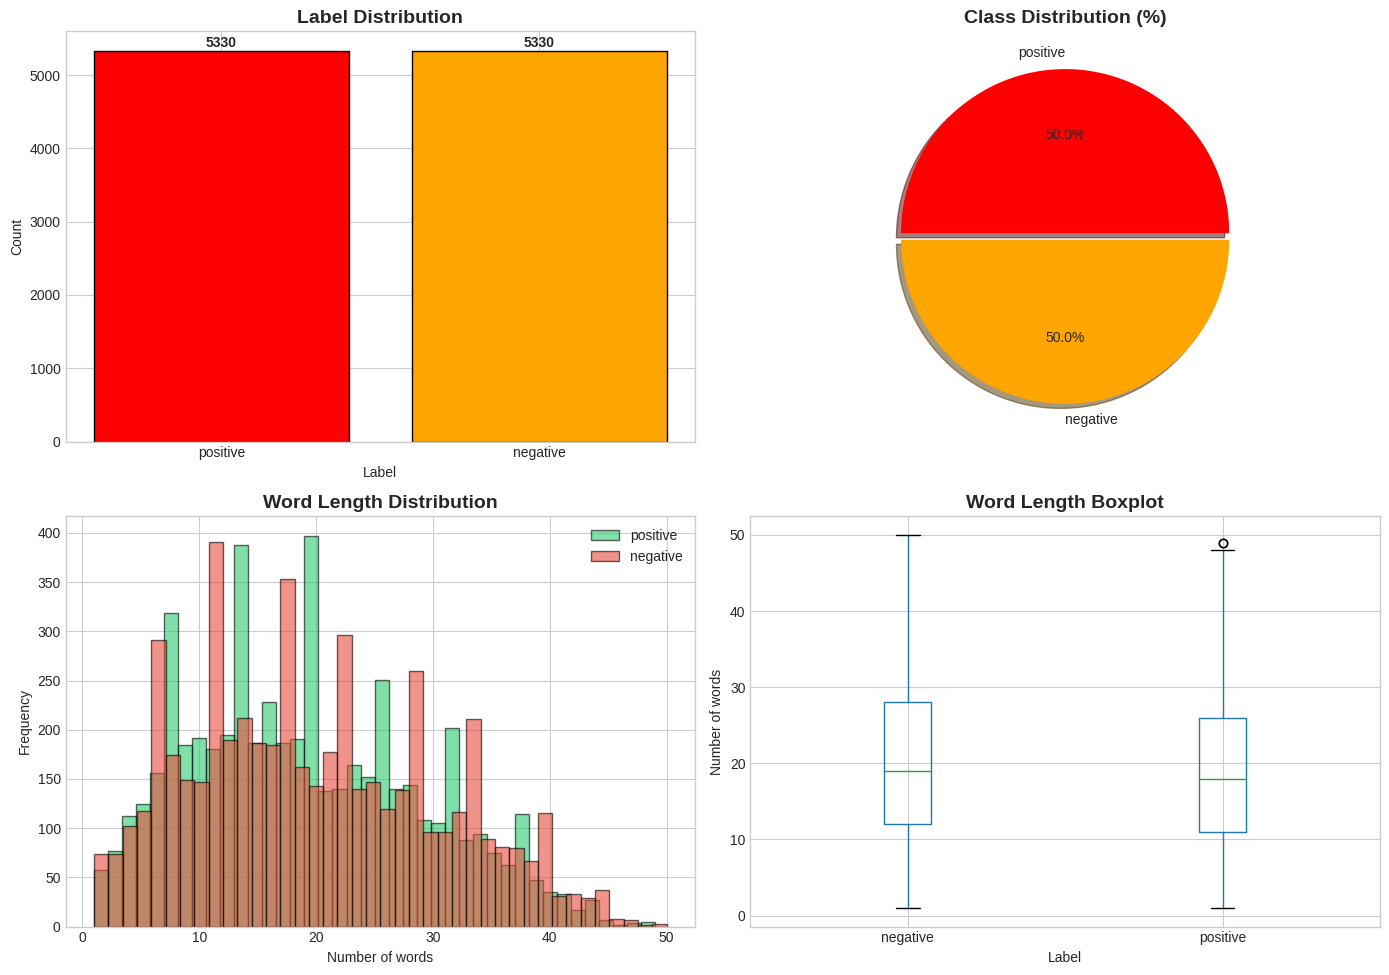



Top 20 words by class


,Positive_Word,Positive_Count,Negative_Word,Negative_Count
0,bir,4512,bir,3986
1,film,3953,film,3290
2,güzel,1255,filmi,1277
3,iyi,1249,kötü,1040
4,filmi,1170,kadar,931
5,bence,757,yok,671
6,kadar,716,filmin,615
7,gerçekten,577,bence,584
8,harika,569,iyi,562
9,kesinlikle,509,degil,522


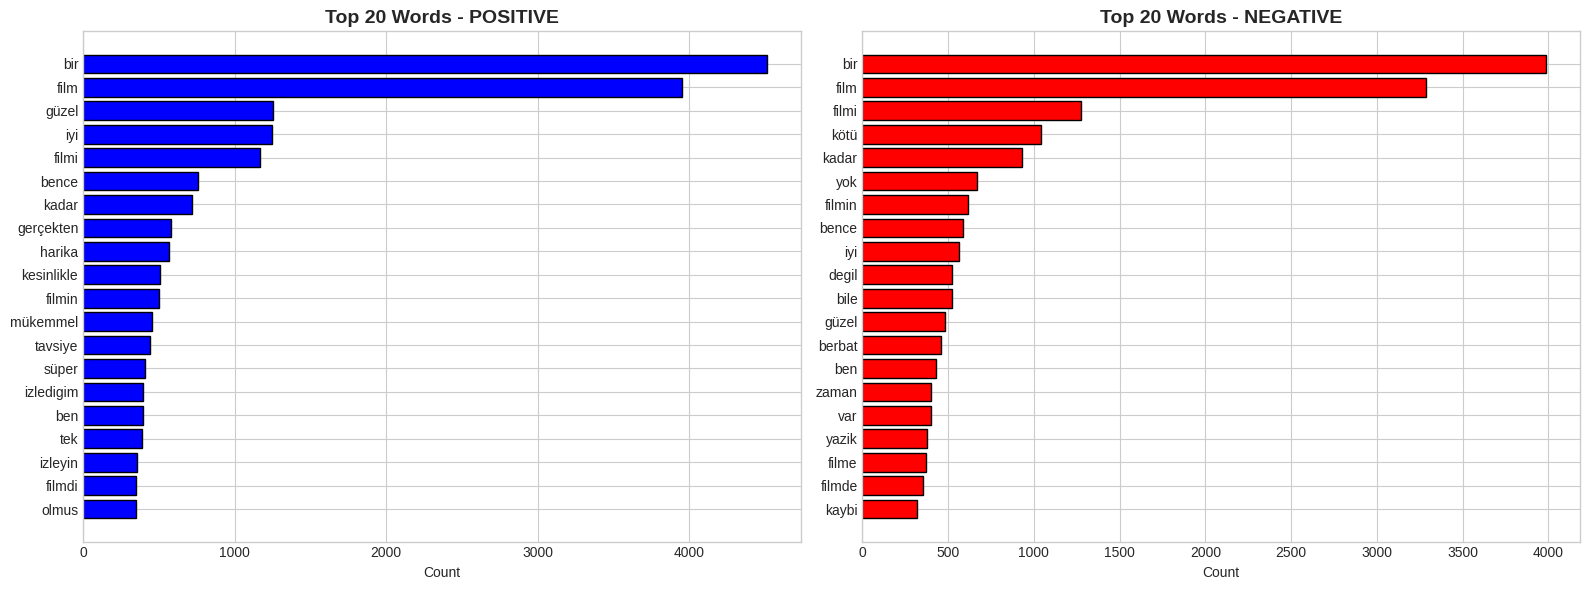



Sample Reviews:




,label_str,text
7571,negative,çok kötü bir filmdi ama daha kötülerini de gör...
5020,positive,çok ama çok güzel bi film bence herkesin mutla...
3404,positive,kesinlikle harika bir film.üstelik her yastan ...
8365,negative,sonunda eklenmis bu film buraya. ben yeni fred...
3145,positive,"özellikle bizim izlememiz gereken bir film, an..."



Dataset ready for train/dev/test split: (10660, 2)


In [ ]:
import re
import zipfile
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# setting style
plt.style.use('seaborn-v0_8-whitegrid')


#to find dataset zip
def find_zip(possible_names=("Turkish_Movie_Sentiment.zip",)):
    for p in [Path("."), Path("/content"), Path.home()]:
        for name in possible_names:
            f = p / name
            if f.exists():
                return f
    for p in [Path("."), Path("/content")]:
        zips = list(p.glob("*.zip"))
        if zips:
            return zips[0]
    raise FileNotFoundError("Zip file not found. Please upload Turkish_Movie_Sentiment.zip")

zip_path = find_zip()
data_dir = Path("Turkish_Movie_Sentiment_extracted")
data_dir.mkdir(exist_ok=True)

#unzip
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(data_dir)

pos_file = data_dir / "tr_polarity.pos"
neg_file = data_dir / "tr_polarity.neg"

#reading dataset (ISO-8859-9 encoding for Turkish)
def read_lines(fp: Path):
    #firts, I try ISO-8859-9,then fallback to utf-8
    for enc in ["iso-8859-9", "utf-8", "latin-1"]:
        try:
            return [ln.strip() for ln in fp.read_text(encoding=enc).splitlines() if ln.strip()]
        except UnicodeDecodeError:
            continue
    return [ln.strip() for ln in fp.read_text(encoding="utf-8", errors="ignore").splitlines() if ln.strip()]

pos_lines = read_lines(pos_file)
neg_lines = read_lines(neg_file)

df = pd.DataFrame({
    "text": pos_lines + neg_lines,
    "label": [1]*len(pos_lines) + [0]*len(neg_lines)
})
df["label_str"] = df["label"].map({1: "positive", 0: "negative"})


print("Dataset Overview:")
print(f"Zip file: {zip_path}")
print(f"Total samples: {len(df)}")
print(f"Positive reviews: {(df.label==1).sum()}")
print(f"Negative reviews: {(df.label==0).sum()}")
print(f"Class balance: {(df.label==1).sum()/len(df)*100:.1f}% / {(df.label==0).sum()/len(df)*100:.1f}%")
display(df.head())

# basic EDA stats
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().apply(len)

print("\n")
print("Length Statistic:")
print("\nOverall statistics:")
display(df[["char_len", "word_len"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T)

print("\nStatistics by label:")
display(df.groupby("label_str")[["char_len", "word_len"]].describe(percentiles=[0.5, 0.9, 0.95]).round(2))

#visualizng
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#label distribution
colors = ['red', 'orange']
counts = df["label_str"].value_counts()
axes[0, 0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0, 0].set_title("Label Distribution", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Label")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

#for pie chart
axes[0, 1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
               colors=colors, explode=(0.02, 0.02), shadow=True)
axes[0, 1].set_title("Class Distribution (%)", fontsize=14, fontweight='bold')

#word length histogram by class
for lab, color in zip(["positive", "negative"], ['#2ecc71', '#e74c3c']):
    axes[1, 0].hist(df[df["label_str"] == lab]["word_len"], bins=40, alpha=0.6,
                    label=lab, color=color, edgecolor='black')
axes[1, 0].set_title("Word Length Distribution", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Number of words")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()

#boxplot for word lengths
df.boxplot(column="word_len", by="label_str", ax=axes[1, 1])
axes[1, 1].set_title("Word Length Boxplot", fontsize=14, fontweight='bold')
plt.suptitle("")
axes[1, 1].set_xlabel("Label")
axes[1, 1].set_ylabel("Number of words")

plt.tight_layout()
plt.show()

#most frequent words
try:
    import nltk
    from nltk.corpus import stopwords
    try:
        tur_stop = set(stopwords.words("turkish"))
    except LookupError:
        nltk.download("stopwords", quiet=True)
        tur_stop = set(stopwords.words("turkish"))
except:
    tur_stop = {'ve','bir','bu','da','de','çok','için','ama','gibi','daha','ile','mi','ben','sen','o','ki','ne'}

token_re = re.compile(r"[a-zçğıöşü]+", re.IGNORECASE)

def top_words(texts, k=20):
    cnt = Counter()
    for t in texts:
        toks = token_re.findall(t.lower())
        toks = [w for w in toks if w not in tur_stop and len(w) > 2]
        cnt.update(toks)
    return cnt.most_common(k)

top_pos = top_words(df[df.label==1]["text"].tolist(), k=20)
top_neg = top_words(df[df.label==0]["text"].tolist(), k=20)

print("\n")
print("Top 20 words by class")
top_df = pd.DataFrame({
    "Positive_Word": [w for w,_ in top_pos],
    "Positive_Count": [c for _,c in top_pos],
    "Negative_Word": [w for w,_ in top_neg],
    "Negative_Count": [c for _,c in top_neg],
})
display(top_df)

#top words visualization
print("\n")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh([w for w,_ in top_pos][::-1], [c for _,c in top_pos][::-1], color='blue', edgecolor='black')
axes[0].set_title("Top 20 Words - POSITIVE", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Count")

axes[1].barh([w for w,_ in top_neg][::-1], [c for _,c in top_neg][::-1], color='red', edgecolor='black')
axes[1].set_title("Top 20 Words - NEGATIVE", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

#sample reviews
print("\n")
print("Sample Reviews:")
print("\n")
display(df.sample(5, random_state=42)[["label_str", "text"]])

#clean up helper columns (keeping df clean for next steps)
df_clean = df[["text", "label"]].copy()
print(f"\nDataset ready for train/dev/test split: {df_clean.shape}")
df = df_clean.copy()

## 2. Train, Validation, and Test Split

After cleaning and preparing the dataset, the samples are divided into training, validation, and test sets. The following proportions are used:

- 70% training set
- 15% validation set
- 15% test set

Stratified splitting is applied to preserve the positive and negative class distributions across all subsets. A fixed random state is used to ensure that the same data partitions can be reproduced in future experiments. The training set is used to optimize model parameters, while the validation set is used for hyperparameter selection and model comparison. The test set is kept separate and is used only for final performance reporting.

Before: 10660  After dedup: 10638  Removed: 22


DATASET SPLIT SUMMARY

Total samples (after dedup): 10638
Random state: 42

Split sizes:
  Train: 7446 (70.0%)
  Dev:   1596 (15.0%)
  Test:  1596 (15.0%)

Class counts:
  Train - pos: 3726, neg: 3720
  Dev   - pos: 799, neg: 797
  Test  - pos: 798, neg: 798

Label proportions:
Train:
 label
1    0.5004
0    0.4996
Name: proportion, dtype: float64


Dev:
 label
1    0.5006
0    0.4994
Name: proportion, dtype: float64


Test:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64

Overlap checks (should be 0):
train ∩ dev : 0
train ∩ test: 0
dev ∩ test  : 0


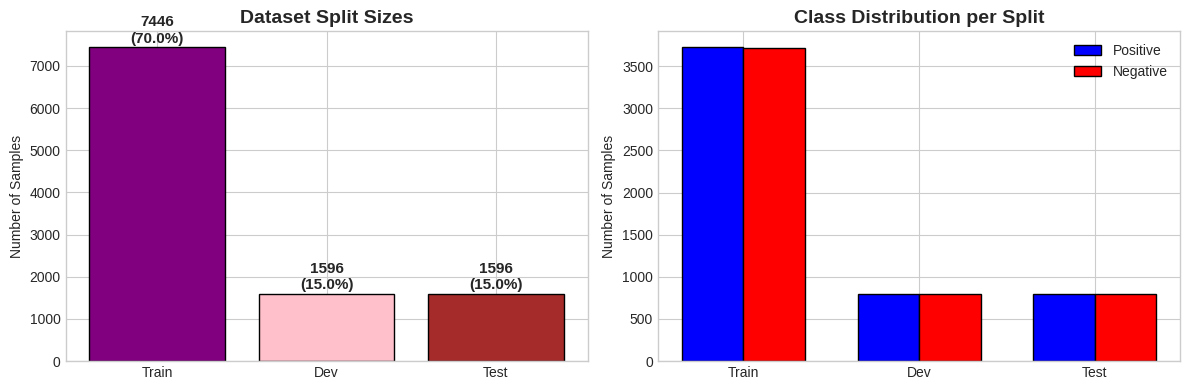



Split completed successfully!
DataFrames: train_df, dev_df, test_df


In [ ]:
import hashlib
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# I fixed random state for reproducibility
RANDOM_STATE = 42

#deduplicate to prevent leakage across splits
before = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
after = len(df)
print(f"Before: {before}  After dedup: {after}  Removed: {before-after}")


#splitting: 70% train, 15% dev, 15% test
#first split: 70% train, 30% temp (dev + test)
#2nd split: 50% of temp = 15% dev, 50% of temp = 15% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["label"]  #maintaing class balance
)

dev_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,        # 50% of 30% = 15%
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

#resetting indices
train_df = train_df.reset_index(drop=True)
dev_df = dev_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

#verifying the splits
print("\n")
print("DATASET SPLIT SUMMARY")
print(f"\nTotal samples (after dedup): {len(df)}")
print(f"Random state: {RANDOM_STATE}")

print(f"\nSplit sizes:")
print(f"  Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Dev:   {len(dev_df)} ({len(dev_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

print(f"\nClass counts:")
print(f"  Train - pos: {(train_df.label==1).sum()}, neg: {(train_df.label==0).sum()}")
print(f"  Dev   - pos: {(dev_df.label==1).sum()}, neg: {(dev_df.label==0).sum()}")
print(f"  Test  - pos: {(test_df.label==1).sum()}, neg: {(test_df.label==0).sum()}")

print("\nLabel proportions:")
print("Train:\n", train_df["label"].value_counts(normalize=True).round(4))
print("\n")
print("Dev:\n", dev_df["label"].value_counts(normalize=True).round(4))
print("\n")
print("Test:\n", test_df["label"].value_counts(normalize=True).round(4))

#overlap check (it should be 0)
def hash_set(series):
    return set(series.apply(lambda s: hashlib.md5(s.encode("utf-8")).hexdigest()))

train_h = hash_set(train_df["text"])
dev_h   = hash_set(dev_df["text"])
test_h  = hash_set(test_df["text"])

print("\nOverlap checks (should be 0):")
print("train ∩ dev :", len(train_h & dev_h))
print("train ∩ test:", len(train_h & test_h))
print("dev ∩ test  :", len(dev_h & test_h))

#visualizing the split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# split sizes
split_names = ['Train', 'Dev', 'Test']
split_sizes = [len(train_df), len(dev_df), len(test_df)]
colors = ['purple', 'pink', 'brown']

axes[0].bar(split_names, split_sizes, color=colors, edgecolor='black')
axes[0].set_title('Dataset Split Sizes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, size in enumerate(split_sizes):
    axes[0].text(i, size + max(5, int(0.01*len(df))), f'{size}\n({size/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

#class distribution per split
x = range(3)
width = 0.35
pos_counts = [(train_df.label==1).sum(), (dev_df.label==1).sum(), (test_df.label==1).sum()]
neg_counts = [(train_df.label==0).sum(), (dev_df.label==0).sum(), (test_df.label==0).sum()]

axes[1].bar([i - width/2 for i in x], pos_counts, width, label='Positive', color='blue', edgecolor='black')
axes[1].bar([i + width/2 for i in x], neg_counts, width, label='Negative', color='red', edgecolor='black')
axes[1].set_title('Class Distribution per Split', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(split_names)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n")
print("Split completed successfully!")
print("DataFrames: train_df, dev_df, test_df")


## 3. BERTurk Fine-Tuning

BERTurk is used as the encoder-only transformer model in this project. It is a BERT-based language model pre-trained specifically on a large Turkish-language corpus. Since encoder-only transformers process text bidirectionally, they are particularly suitable for classification tasks where understanding the complete context of a sentence is important. The pre-trained BERTurk tokenizer is used to convert the movie reviews into token sequences. A sequence-classification head is then fine-tuned for binary sentiment prediction.

Multiple experiments are conducted using different combinations of:

- Learning rate
- Batch size
- Number of training epochs
- Maximum sequence length
- Weight decay
- Gradient accumulation

The validation set is used to select the strongest configuration before the final model is evaluated on the test set.

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1262209846.py:177: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.317900,0.220091,0.923559,0.923620,0.923567,0.923557,0.923556
2,0.214800,0.212610,0.925439,0.925911,0.925460,0.925420,0.925419
3,0.156100,0.215159,0.927318,0.927499,0.927306,0.927309,0.927310



DEV Classification Report:
              precision    recall  f1-score   support

 Negative(0)       0.94      0.92      0.93       797
 Positive(1)       0.92      0.94      0.93       799

    accuracy                           0.93      1596
   macro avg       0.93      0.93      0.93      1596
weighted avg       0.93      0.93      0.93      1596


DEV Results (sorted by dev_f1_macro):


,model,run_name,lr,train_bs,grad_acc,epochs,max_len,weight_decay,warmup_ratio,dev_accuracy,dev_f1_macro,dev_f1_weighted,dev_precision_macro,dev_recall_macro,best_checkpoint
0,BERTurk (encoder-only),berturk_run1_lr2e-5_bs16_ep3_len128_wd0.01,0.00002,16,1,3,128,0.01,0.06,0.939223,0.939213,0.939214,0.939483,0.939208,outputs_berturk/berturk_run1_lr2e-5_bs16_ep3_l...
1,BERTurk (encoder-only),berturk_run2_lr3e-5_bs16_ep4_len256_wd0.0,0.00003,16,1,4,256,0.00,0.10,0.936717,0.936717,0.936716,0.936731,0.936721,outputs_berturk/berturk_run2_lr3e-5_bs16_ep4_l...
2,BERTurk (encoder-only),berturk_run3_lr1e-5_effbs32_ep3_len128_wd0.01_...,0.00001,16,2,3,128,0.01,0.06,0.927318,0.927309,0.927310,0.927499,0.927306,outputs_berturk/berturk_run3_lr1e-5_effbs32_ep...



Saved: results/berturk_dev_results.csv

Best BERTurk run on DEV (by macro-F1): berturk_run1_lr2e-5_bs16_ep3_len128_wd0.01
Best checkpoint: outputs_berturk/berturk_run1_lr2e-5_bs16_ep3_len128_wd0.01/checkpoint-1398

Note: I did NOT use the test set here. Test evaluation will be done only in the final reporting section.


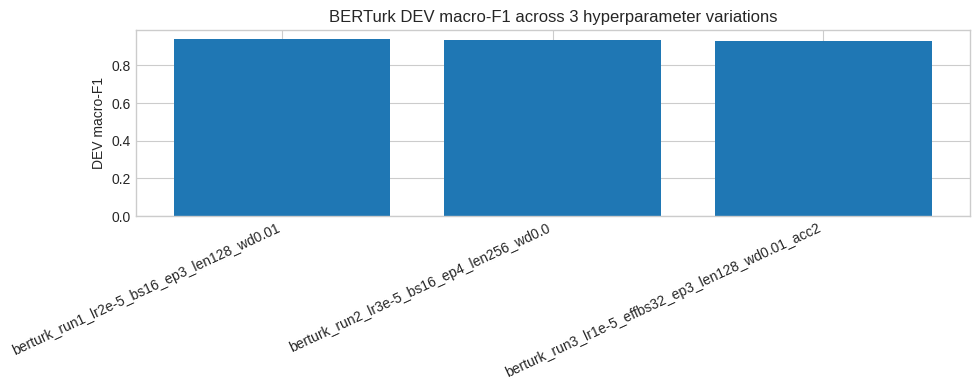

In [ ]:
#BERTurk Model (Encoder-only) Finetuning + 3 Hyperparam Variations (DEV-based selection)
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

#reproducibility
SEED = 42
set_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

#safety checks
assert "train_df" in globals() and "dev_df" in globals() and "test_df" in globals(), \
    "train_df/dev_df/test_df not found. Please run cell 2 first."

#this cell must not tune on test. I will use test only at the very end.
train_df_ = train_df[["text", "label"]].copy()
dev_df_   = dev_df[["text", "label"]].copy()

train_ds = Dataset.from_pandas(train_df_, preserve_index=False)
dev_ds   = Dataset.from_pandas(dev_df_, preserve_index=False)

#model/tokenizer (BERTurk)
MODEL_NAME = "dbmdz/bert-base-turkish-cased"
NUM_LABELS = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples, max_length=128):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=max_length
    )

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)  #dynamic padding (faster than padding="max_length")

#metrics (use MACRO F1; dataset is balanced and macro is standard)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_w,  # optional (nice to report)
    }

#3 hyperparameter variations (change >=3 params across runs)
run_configs = [
    {
        "run_name": "berturk_run1_lr2e-5_bs16_ep3_len128_wd0.01",
        "learning_rate": 2e-5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 3,
        "weight_decay": 0.01,
        "max_length": 128,
        "warmup_ratio": 0.06,
        "gradient_accumulation_steps": 1,
        "early_stop_patience": 2,
    },
    {
        "run_name": "berturk_run2_lr3e-5_bs16_ep4_len256_wd0.0",
        "learning_rate": 3e-5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 4,
        "weight_decay": 0.0,
        "max_length": 256,
        "warmup_ratio": 0.10,
        "gradient_accumulation_steps": 1,
        "early_stop_patience": 2,
    },
    {
        "run_name": "berturk_run3_lr1e-5_effbs32_ep3_len128_wd0.01_acc2",
        # effective batch size like 32
        "learning_rate": 1e-5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 3,
        "weight_decay": 0.01,
        "max_length": 128,
        "warmup_ratio": 0.06,
        "gradient_accumulation_steps": 2,
        "early_stop_patience": 2,
    },
]

#train + evaluate
def train_one_run(cfg):
    print("\n" + "."*95)
    print("Starting:", cfg["run_name"])
    print({k: cfg[k] for k in cfg if k != "run_name"})
    print("\n")

    #tokenize
    train_tok = train_ds.map(lambda x: tokenize_fn(x, max_length=cfg["max_length"]), batched=True)
    dev_tok   = dev_ds.map(lambda x: tokenize_fn(x, max_length=cfg["max_length"]), batched=True)

    #keeping only model columns
    keep_cols = {"input_ids", "attention_mask", "label"}
    train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in keep_cols])
    dev_tok   = dev_tok.remove_columns([c for c in dev_tok.column_names if c not in keep_cols])

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

    output_dir = os.path.join("outputs_berturk", cfg["run_name"])
    os.makedirs(output_dir, exist_ok=True)

    # version-compatible TrainingArguments
    common_kwargs = dict(
        output_dir=output_dir,
        run_name=cfg["run_name"],
        seed=SEED,

        learning_rate=cfg["learning_rate"],
        per_device_train_batch_size=cfg["per_device_train_batch_size"],
        per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
        num_train_epochs=cfg["num_train_epochs"],
        weight_decay=cfg["weight_decay"],
        warmup_ratio=cfg["warmup_ratio"],
        gradient_accumulation_steps=cfg["gradient_accumulation_steps"],

        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",  # UPDATED: use metric key returned by compute_metrics
        greater_is_better=True,
        save_total_limit=2,

        logging_strategy="steps",
        logging_steps=100,
        report_to="none",

        fp16=torch.cuda.is_available(),
    )

    #transformers compat (evaluation_strategy vs eval_strategy)
    try:
        args = TrainingArguments(**common_kwargs, evaluation_strategy="epoch")
    except TypeError:
        args = TrainingArguments(**common_kwargs, eval_strategy="epoch")

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=dev_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg["early_stop_patience"])],
    )

    trainer.train()
    dev_metrics = trainer.evaluate()

    #DEV classification report (allowed; still I am not using test)
    dev_pred = trainer.predict(dev_tok)
    dev_preds = np.argmax(dev_pred.predictions, axis=-1)
    dev_labels = dev_pred.label_ids
    print("\nDEV Classification Report:")
    print(classification_report(dev_labels, dev_preds, target_names=["Negative(0)", "Positive(1)"]))

    #Clean GPU cache between runs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    #collecting results
    row = {
        "model": "BERTurk (encoder-only)",
        "run_name": cfg["run_name"],
        "lr": cfg["learning_rate"],
        "train_bs": cfg["per_device_train_batch_size"],
        "grad_acc": cfg["gradient_accumulation_steps"],
        "epochs": cfg["num_train_epochs"],
        "max_len": cfg["max_length"],
        "weight_decay": cfg["weight_decay"],
        "warmup_ratio": cfg["warmup_ratio"],
        "dev_accuracy": dev_metrics.get("eval_accuracy"),
        "dev_f1_macro": dev_metrics.get("eval_f1_macro"),
        "dev_f1_weighted": dev_metrics.get("eval_f1_weighted"),
        "dev_precision_macro": dev_metrics.get("eval_precision_macro"),
        "dev_recall_macro": dev_metrics.get("eval_recall_macro"),
        "best_checkpoint": trainer.state.best_model_checkpoint,
    }
    return row


#running all 3 experiments
all_results = []
for cfg in run_configs:
    all_results.append(train_one_run(cfg))

results_df = pd.DataFrame(all_results).sort_values("dev_f1_macro", ascending=False).reset_index(drop=True)
print("\nDEV Results (sorted by dev_f1_macro):")
display(results_df)

#savşng for final comparison table
os.makedirs("results", exist_ok=True)
results_df.to_csv("results/berturk_dev_results.csv", index=False)
print("\nSaved: results/berturk_dev_results.csv")

best_run = results_df.iloc[0]
print(f"\nBest BERTurk run on DEV (by macro-F1): {best_run['run_name']}")
print(f"Best checkpoint: {best_run['best_checkpoint']}")
print("\nNote: I did NOT use the test set here. Test evaluation will be done only in the final reporting section.")

#simple visualization (DEV only)
plt.figure(figsize=(10, 4))
plt.bar(results_df["run_name"], results_df["dev_f1_macro"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("DEV macro-F1")
plt.title("BERTurk DEV macro-F1 across 3 hyperparameter variations")
plt.tight_layout()
plt.show()


## 4. Decoder-Only Model Fine-Tuning

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Could not load tokenizer for dbmdz/gpt2-turkish-cased: OSError


tokenizer_config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at ytu-ce-cosmos/turkish-gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1696939629.py:207: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.258000,0.239382,0.905388,0.906590,0.905355,0.905313,0.905317
2,0.151500,0.266347,0.916040,0.917005,0.916010,0.915987,0.915990
3,0.133000,0.360077,0.913534,0.913708,0.913521,0.913523,0.913524



DEV Classification Report:
              precision    recall  f1-score   support

 Negative(0)       0.94      0.89      0.91       797
 Positive(1)       0.90      0.94      0.92       799

    accuracy                           0.92      1596
   macro avg       0.92      0.92      0.92      1596
weighted avg       0.92      0.92      0.92      1596


DEV Results (sorted by dev_f1_macro):


,model,run_name,lr,train_bs,grad_acc,epochs,max_len,weight_decay,warmup_ratio,dev_accuracy,dev_f1_macro,dev_f1_weighted,dev_precision_macro,dev_recall_macro,best_checkpoint
0,Decoder-only (ytu-ce-cosmos/turkish-gpt2),decoder_run3_lr1e-5_effbs16_ep3_len128_wd0.01_...,0.00001,8,2,3,128,0.01,0.06,0.916040,0.915987,0.915990,0.917005,0.916010,outputs_decoder_only/decoder_run3_lr1e-5_effbs...
1,Decoder-only (ytu-ce-cosmos/turkish-gpt2),decoder_run2_lr3e-5_bs8_ep4_len256_wd0.0,0.00003,8,1,4,256,0.00,0.10,0.912281,0.912279,0.912280,0.912293,0.912277,outputs_decoder_only/decoder_run2_lr3e-5_bs8_e...
2,Decoder-only (ytu-ce-cosmos/turkish-gpt2),decoder_run1_lr5e-5_bs8_ep3_len128_wd0.01,0.00005,8,1,3,128,0.01,0.06,0.898496,0.898469,0.898471,0.898868,0.898477,outputs_decoder_only/decoder_run1_lr5e-5_bs8_e...



Saved: results/decoder_only_dev_results.csv

Best Decoder-only run on DEV (by macro-F1): decoder_run3_lr1e-5_effbs16_ep3_len128_wd0.01_acc2
Best checkpoint: outputs_decoder_only/decoder_run3_lr1e-5_effbs16_ep3_len128_wd0.01_acc2/checkpoint-932

Note: Again, I did not use the test set here. Test evaluation will be done only in the final reporting section.


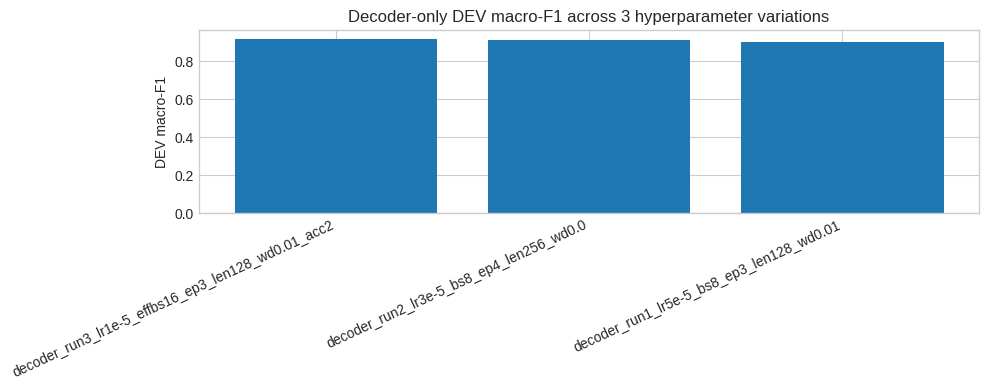

In [ ]:

#selected Decoder-Only Model Finetuning + 3 Hyperparam Variations (DEV-based selection)
#note: I do not use the test set here. Test evaluation will be done only in the final reporting section.

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

#reproducibility
SEED = 42
set_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

#safety checks
assert "train_df" in globals() and "dev_df" in globals() and "test_df" in globals(), \
    "train_df/dev_df/test_df not found. Please run cell 2 first."

#important: this cell must not tune on test
train_df_ = train_df[["text", "label"]].copy()
dev_df_   = dev_df[["text", "label"]].copy()

train_ds = Dataset.from_pandas(train_df_, preserve_index=False)
dev_ds   = Dataset.from_pandas(dev_df_, preserve_index=False)


#decoder-only model choice
#I will try a Turkish GPT-2 model first; fallback if it doesn't exist in my environment.
CANDIDATE_MODELS = [
    "dbmdz/gpt2-turkish-cased",
    "ytu-ce-cosmos/turkish-gpt2",
    "gpt2",  #final fallback (it is not Turkish-specific, but ensures the cell can run)
]

MODEL_NAME = None
tokenizer = None

for name in CANDIDATE_MODELS:
    try:
        tok = AutoTokenizer.from_pretrained(name)
        MODEL_NAME = name
        tokenizer = tok
        break
    except Exception as e:
        print(f"Could not load tokenizer for {name}: {type(e).__name__}")

assert MODEL_NAME is not None, "Could not load any decoder-only model tokenizer."

print(f"\nSelected decoder-only model: {MODEL_NAME}")

# GPT-style tokenizers often have no pad_token -> setting it to eos_token for batching
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Tokenizer had no pad_token. Set pad_token = eos_token.")

#dynamic padding collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_fn(examples, max_length=128):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=max_length
    )

#metrics (macro-F1 for selection; weighted also reported)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,        # used for best model selection
        "f1_weighted": f1_w
    }

#3 Hyperparameter variations (>=3 params differ across runs)
run_configs = [
    {
        "run_name": "decoder_run1_lr5e-5_bs8_ep3_len128_wd0.01",
        "learning_rate": 5e-5,
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 16,
        "num_train_epochs": 3,
        "weight_decay": 0.01,
        "max_length": 128,
        "warmup_ratio": 0.06,
        "gradient_accumulation_steps": 1,
        "early_stop_patience": 2,
    },
    {
        "run_name": "decoder_run2_lr3e-5_bs8_ep4_len256_wd0.0",
        "learning_rate": 3e-5,
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 16,
        "num_train_epochs": 4,
        "weight_decay": 0.0,
        "max_length": 256,
        "warmup_ratio": 0.10,
        "gradient_accumulation_steps": 1,
        "early_stop_patience": 2,
    },
    {
        "run_name": "decoder_run3_lr1e-5_effbs16_ep3_len128_wd0.01_acc2",
        # effective batch size ~16 via grad accumulation (T4-safe)
        "learning_rate": 1e-5,
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 16,
        "num_train_epochs": 3,
        "weight_decay": 0.01,
        "max_length": 128,
        "warmup_ratio": 0.06,
        "gradient_accumulation_steps": 2,
        "early_stop_patience": 2,
    },
]

# train + evaluate helper
def train_one_run(cfg):
    print("\n")
    print("Starting:", cfg["run_name"])
    print({k: cfg[k] for k in cfg if k != "run_name"})
    print("."*95)

    #tokenize (run-specific max_length)
    train_tok = train_ds.map(lambda x: tokenize_fn(x, max_length=cfg["max_length"]), batched=True)
    dev_tok   = dev_ds.map(lambda x: tokenize_fn(x, max_length=cfg["max_length"]), batched=True)

    #keeping only model columns
    keep_cols = {"input_ids", "attention_mask", "label"}
    train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in keep_cols])
    dev_tok   = dev_tok.remove_columns([c for c in dev_tok.column_names if c not in keep_cols])

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    # ensuring model has a pad_token_id (important for GPT-style models)
    if getattr(model.config, "pad_token_id", None) is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    # some decoder-only models benefit from disabling cache during training
    if hasattr(model.config, "use_cache"):
        model.config.use_cache = False

    output_dir = os.path.join("outputs_decoder_only", cfg["run_name"])
    os.makedirs(output_dir, exist_ok=True)

    #version-compatible training arguments
    common_kwargs = dict(
        output_dir=output_dir,
        run_name=cfg["run_name"],
        seed=SEED,

        learning_rate=cfg["learning_rate"],
        per_device_train_batch_size=cfg["per_device_train_batch_size"],
        per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
        num_train_epochs=cfg["num_train_epochs"],
        weight_decay=cfg["weight_decay"],
        warmup_ratio=cfg["warmup_ratio"],
        gradient_accumulation_steps=cfg["gradient_accumulation_steps"],

        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,

        logging_strategy="steps",
        logging_steps=100,
        report_to="none",

        fp16=torch.cuda.is_available(),
    )

    try:
        args = TrainingArguments(**common_kwargs, evaluation_strategy="epoch")
    except TypeError:
        args = TrainingArguments(**common_kwargs, eval_strategy="epoch")

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=dev_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg["early_stop_patience"])],
    )

    trainer.train()
    dev_metrics = trainer.evaluate()

    #DEV classification report (still no test)
    dev_pred = trainer.predict(dev_tok)
    dev_preds = np.argmax(dev_pred.predictions, axis=-1)
    dev_labels = dev_pred.label_ids
    print("\nDEV Classification Report:")
    print(classification_report(dev_labels, dev_preds, target_names=["Negative(0)", "Positive(1)"]))

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    row = {
        "model": f"Decoder-only ({MODEL_NAME})",
        "run_name": cfg["run_name"],
        "lr": cfg["learning_rate"],
        "train_bs": cfg["per_device_train_batch_size"],
        "grad_acc": cfg["gradient_accumulation_steps"],
        "epochs": cfg["num_train_epochs"],
        "max_len": cfg["max_length"],
        "weight_decay": cfg["weight_decay"],
        "warmup_ratio": cfg["warmup_ratio"],
        "dev_accuracy": dev_metrics.get("eval_accuracy"),
        "dev_f1_macro": dev_metrics.get("eval_f1_macro"),
        "dev_f1_weighted": dev_metrics.get("eval_f1_weighted"),
        "dev_precision_macro": dev_metrics.get("eval_precision_macro"),
        "dev_recall_macro": dev_metrics.get("eval_recall_macro"),
        "best_checkpoint": trainer.state.best_model_checkpoint,
    }
    return row

#runming all 3 experiments
all_results = []
for cfg in run_configs:
    all_results.append(train_one_run(cfg))

results_df_decoder = pd.DataFrame(all_results).sort_values("dev_f1_macro", ascending=False).reset_index(drop=True)
print("\nDEV Results (sorted by dev_f1_macro):")
display(results_df_decoder)

#saving for final comparison table
os.makedirs("results", exist_ok=True)
results_df_decoder.to_csv("results/decoder_only_dev_results.csv", index=False)
print("\nSaved: results/decoder_only_dev_results.csv")

best_run = results_df_decoder.iloc[0]
print(f"\nBest Decoder-only run on DEV (by macro-F1): {best_run['run_name']}")
print(f"Best checkpoint: {best_run['best_checkpoint']}")
print("\nNote: Again, I did not use the test set here. Test evaluation will be done only in the final reporting section.")

#simple visualization (DEV only)
plt.figure(figsize=(10, 4))
plt.bar(results_df_decoder["run_name"], results_df_decoder["dev_f1_macro"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("DEV macro-F1")
plt.title("Decoder-only DEV macro-F1 across 3 hyperparameter variations")
plt.tight_layout()
plt.show()


## 5. Encoder-Decoder Model Fine-Tuning

mT5-small is used as the encoder-decoder transformer model. mT5 is a multilingual version of the Text-to-Text Transfer Transformer and supports Turkish among many other languages. Instead of using a conventional classification head, the sentiment analysis task is formulated as a text-generation problem.

Each movie review is formatted using the following input structure:

- duygu analizi: <movie review>

The expected target output is one of the following labels:

- pozitif
- negatif

The model is trained to generate the appropriate sentiment label for each review. During evaluation, the generated outputs are decoded and converted into binary class predictions. Different learning rates, batch sizes, sequence lengths, epoch counts, and weight-decay values are tested to determine the most effective configuration.

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.342500,0.180496,0.730576,0.753091,0.730389,0.724343,0.724395
2,0.186600,0.145974,0.822682,0.823045,0.822703,0.822638,0.822635
3,0.203200,0.137099,0.838972,0.839088,0.838984,0.838962,0.838960


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



DEV Classification Report (generated labels):
              precision    recall  f1-score   support

 Negative(0)       0.83      0.85      0.84       797
 Positive(1)       0.85      0.83      0.84       799

    accuracy                           0.84      1596
   macro avg       0.84      0.84      0.84      1596
weighted avg       0.84      0.84      0.84      1596


DEV Results (sorted by dev_f1_macro):


,model,run_name,lr,train_bs,grad_acc,epochs,src_len,tgt_len,weight_decay,warmup_ratio,dev_accuracy,dev_f1_macro,dev_f1_weighted,dev_precision_macro,dev_recall_macro,best_checkpoint
0,Encoder-Decoder (google/mt5-small),encdec_run2_lr2e-4_bs8_ep4_src384_tgt8_wd0.0,0.0002,8,1,4,384,8,0.00,0.10,0.878446,0.878439,0.878440,0.878509,0.878438,outputs_encdec/encdec_run2_lr2e-4_bs8_ep4_src3...
1,Encoder-Decoder (google/mt5-small),encdec_run1_lr3e-4_bs8_ep3_src256_tgt8_wd0.01,0.0003,8,1,3,256,8,0.01,0.06,0.877193,0.877144,0.877147,0.877739,0.877169,outputs_encdec/encdec_run1_lr3e-4_bs8_ep3_src2...
2,Encoder-Decoder (google/mt5-small),encdec_run3_lr1e-4_effbs16_ep3_src256_tgt8_wd0...,0.0001,8,2,3,256,8,0.01,0.06,0.838972,0.838962,0.838960,0.839088,0.838984,outputs_encdec/encdec_run3_lr1e-4_effbs16_ep3_...



Saved: results/encdec_dev_results.csv

Best Encoder-Decoder run on DEV (by macro-F1): encdec_run2_lr2e-4_bs8_ep4_src384_tgt8_wd0.0
Best checkpoint: outputs_encdec/encdec_run2_lr2e-4_bs8_ep4_src384_tgt8_wd0.0/checkpoint-3724

Note: Again, I did not use the test set here. Test evaluation will be done only in the final reporting section.


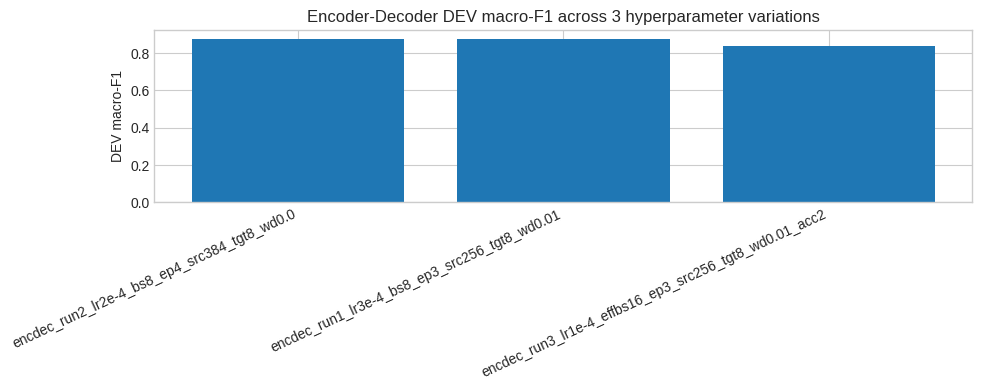

In [ ]:
#Selected Encoder-Decoder Model Finetuning + 3 Hyperparam Variations (DEV-based selection)
# my approach: sentiment classification as text generation
# input : "duygu analizi: <yorum>"
# target: "pozitif" / "negatif"
# Again, bo test usage here (test only in final reporting).

import os, re, gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    set_seed
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

#reproducibility
SEED = 42
set_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

#safety checks
assert "train_df" in globals() and "dev_df" in globals() and "test_df" in globals(), \
    "train_df/dev_df/test_df not found. Please run cell 2 first."

#prepare train/dev only (NO TEST)
train_df_ = train_df[["text", "label"]].copy()
dev_df_   = dev_df[["text", "label"]].copy()

label_to_text = {1: "pozitif", 0: "negatif"}

def add_prompt_target(df):
    out = df.copy()
    out["input_text"]  = out["text"].apply(lambda t: f"duygu analizi: {t}")
    out["target_text"] = out["label"].map(label_to_text)
    return out

train_df_ = add_prompt_target(train_df_)
dev_df_   = add_prompt_target(dev_df_)

train_ds = Dataset.from_pandas(train_df_[["input_text", "target_text"]], preserve_index=False)
dev_ds   = Dataset.from_pandas(dev_df_[["input_text", "target_text"]], preserve_index=False)

#model choice (Encoder-Decoder)
CANDIDATE_MODELS = ["google/mt5-small", "google/mt5-base"]

MODEL_NAME = None
tokenizer = None
for name in CANDIDATE_MODELS:
    try:
        tokenizer = AutoTokenizer.from_pretrained(name)
        MODEL_NAME = name
        break
    except Exception as e:
        print(f"Could not load {name}: {type(e).__name__}")

assert MODEL_NAME is not None, "Could not load any encoder-decoder model tokenizer."
print(f"\nSelected encoder-decoder model: {MODEL_NAME}")

#generated text -> class (robust)
_non_alnum = re.compile(r"[^a-zçğıöşü]+", re.IGNORECASE)

def normalize_text(s: str) -> str:
    s = (s or "").lower().strip()
    s = _non_alnum.sub(" ", s)
    return " ".join(s.split())

def pred_text_to_label(s: str) -> int:
    s = normalize_text(s)
    if "pozitif" in s or "positive" in s:
        return 1
    if "negatif" in s or "negative" in s:
        return 0
    tok = s.split(" ")[0] if s else ""
    if tok.startswith("p"):
        return 1
    if tok.startswith("n"):
        return 0
    return 0

#metrics on generated outputs
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]

    # labels contain -100 padding for seq2seq; replace to decode
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    pred_texts  = tokenizer.batch_decode(preds, skip_special_tokens=True)
    label_texts = tokenizer.batch_decode(labels, skip_special_tokens=True)

    y_pred = np.array([pred_text_to_label(t) for t in pred_texts])
    y_true = np.array([pred_text_to_label(t) for t in label_texts])

    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_w,
    }

# 3 hyperparameter variations (>=3 params differ)
run_configs = [
    dict(
        run_name="encdec_run1_lr3e-4_bs8_ep3_src256_tgt8_wd0.01",
        learning_rate=3e-4,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_ratio=0.06,
        gradient_accumulation_steps=1,
        max_source_length=256,
        max_target_length=8,
        early_stop_patience=2,
    ),
    dict(
        run_name="encdec_run2_lr2e-4_bs8_ep4_src384_tgt8_wd0.0",
        learning_rate=2e-4,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=4,
        weight_decay=0.0,
        warmup_ratio=0.10,
        gradient_accumulation_steps=1,
        max_source_length=384,
        max_target_length=8,
        early_stop_patience=2,
    ),
    dict(
        run_name="encdec_run3_lr1e-4_effbs16_ep3_src256_tgt8_wd0.01_acc2",
        learning_rate=1e-4,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_ratio=0.06,
        gradient_accumulation_steps=2,  # effective bs about 16
        max_source_length=256,
        max_target_length=8,
        early_stop_patience=2,
    ),
]

#tokenization per run (lengths vary) + crash-proof label sanitize
def make_tokenized_datasets(cfg):
    def preprocess(batch):
        # tokenize inputs
        model_inputs = tokenizer(
            batch["input_text"],
            truncation=True,
            max_length=cfg["max_source_length"],
            padding=False,
        )

        # tokenize targets separately (MOST compatible; avoids max_target_length kw)
        with tokenizer.as_target_tokenizer():
            labels = tokenizer(
                batch["target_text"],
                truncation=True,
                max_length=cfg["max_target_length"],
                padding=False,
            )

        model_inputs["labels"] = labels["input_ids"]

        fixed_labels = []
        for l in model_inputs["labels"]:
            if isinstance(l, int):
                fixed_labels.append([l])
            else:
                fixed_labels.append(l)
        model_inputs["labels"] = fixed_labels

        return model_inputs

    train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
    dev_tok   = dev_ds.map(preprocess, batched=True, remove_columns=dev_ds.column_names)
    return train_tok, dev_tok

#train + evaluate part
def train_one_run(cfg):
    print("\n")
    print("Starting:", cfg["run_name"])
    print({k: cfg[k] for k in cfg if k != "run_name"})
    print("."*95)

    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

    train_tok, dev_tok = make_tokenized_datasets(cfg)

    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

    output_dir = os.path.join("outputs_encdec", cfg["run_name"])
    os.makedirs(output_dir, exist_ok=True)

    use_bf16 = bool(torch.cuda.is_available() and torch.cuda.is_bf16_supported())
    use_fp16 = bool(torch.cuda.is_available() and (not use_bf16))
    print(f"Mixed precision -> bf16: {use_bf16}, fp16: {use_fp16}")

    common_kwargs = dict(
        output_dir=output_dir,
        run_name=cfg["run_name"],
        seed=SEED,

        learning_rate=cfg["learning_rate"],
        per_device_train_batch_size=cfg["per_device_train_batch_size"],
        per_device_eval_batch_size=cfg["per_device_eval_batch_size"],
        num_train_epochs=cfg["num_train_epochs"],
        weight_decay=cfg["weight_decay"],
        warmup_ratio=cfg["warmup_ratio"],
        gradient_accumulation_steps=cfg["gradient_accumulation_steps"],

        predict_with_generate=True,
        generation_max_length=cfg["max_target_length"],
        generation_num_beams=1,

        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,

        logging_strategy="steps",
        logging_steps=100,
        report_to="none",

        fp16=use_fp16,
        bf16=use_bf16,
    )

    #version-compatible strategy name
    try:
        args = Seq2SeqTrainingArguments(**common_kwargs, evaluation_strategy="epoch")
    except TypeError:
        args = Seq2SeqTrainingArguments(**common_kwargs, eval_strategy="epoch")

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=dev_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg["early_stop_patience"])],
    )

    trainer.train()
    dev_metrics = trainer.evaluate()

    #DEV report
    dev_pred = trainer.predict(dev_tok)
    preds = dev_pred.predictions
    if isinstance(preds, tuple):
        preds = preds[0]

    labels = dev_pred.label_ids
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    pred_texts = tokenizer.batch_decode(preds, skip_special_tokens=True)
    true_texts = tokenizer.batch_decode(labels, skip_special_tokens=True)

    y_pred = np.array([pred_text_to_label(t) for t in pred_texts])
    y_true = np.array([pred_text_to_label(t) for t in true_texts])

    print("\nDEV Classification Report (generated labels):")
    print(classification_report(y_true, y_pred, target_names=["Negative(0)", "Positive(1)"]))

    row = {
        "model": f"Encoder-Decoder ({MODEL_NAME})",
        "run_name": cfg["run_name"],
        "lr": cfg["learning_rate"],
        "train_bs": cfg["per_device_train_batch_size"],
        "grad_acc": cfg["gradient_accumulation_steps"],
        "epochs": cfg["num_train_epochs"],
        "src_len": cfg["max_source_length"],
        "tgt_len": cfg["max_target_length"],
        "weight_decay": cfg["weight_decay"],
        "warmup_ratio": cfg["warmup_ratio"],
        "dev_accuracy": dev_metrics.get("eval_accuracy"),
        "dev_f1_macro": dev_metrics.get("eval_f1_macro"),
        "dev_f1_weighted": dev_metrics.get("eval_f1_weighted"),
        "dev_precision_macro": dev_metrics.get("eval_precision_macro"),
        "dev_recall_macro": dev_metrics.get("eval_recall_macro"),
        "best_checkpoint": trainer.state.best_model_checkpoint,
    }

    #cleanup between runs
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return row


# running all 3 experiments
all_results = []
for cfg in run_configs:
    all_results.append(train_one_run(cfg))

results_df_encdec = pd.DataFrame(all_results).sort_values("dev_f1_macro", ascending=False).reset_index(drop=True)
print("\nDEV Results (sorted by dev_f1_macro):")
display(results_df_encdec)

os.makedirs("results", exist_ok=True)
results_df_encdec.to_csv("results/encdec_dev_results.csv", index=False)
print("\nSaved: results/encdec_dev_results.csv")

best_run = results_df_encdec.iloc[0]
print(f"\nBest Encoder-Decoder run on DEV (by macro-F1): {best_run['run_name']}")
print(f"Best checkpoint: {best_run['best_checkpoint']}")
print("\nNote: Again, I did not use the test set here. Test evaluation will be done only in the final reporting section.")

plt.figure(figsize=(10, 4))
plt.bar(results_df_encdec["run_name"], results_df_encdec["dev_f1_macro"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("DEV macro-F1")
plt.title("Encoder-Decoder DEV macro-F1 across 3 hyperparameter variations")
plt.tight_layout()
plt.show()


## 6. Model Performance Comparison

The three transformer architectures are compared using their macro F1-scores and classification accuracies. Macro F1-score is used as the main evaluation metric because it calculates the F1-score independently for each sentiment class and gives equal importance to positive and negative reviews. Hyperparameter selection is performed using validation-set results. After the best configuration for each architecture is selected, the corresponding model is evaluated on the test set.

The comparison focuses on:

- Classification performance
- Training stability
- Computational requirements
- Sensitivity to hyperparameter changes
- Suitability of each architecture for sentiment classification

This evaluation provides insight into the advantages and limitations of encoder-only, decoder-only, and encoder-decoder transformer models for Turkish text classification.

FINAL MODEL COMPARISON - TEST SET EVALUATION



Note: This is the only section where I use the test set!
Test set size: 1596 samples

......................................................................
1) Evaluating BERTurk (Encoder-only) on TEST set...


Best config: berturk_run1_lr2e-5_bs16_ep3_len128_wd0.01
Loading checkpoint: outputs_berturk/berturk_run1_lr2e-5_bs16_ep3_len128_wd0.01/checkpoint-1398


Map:   0%|          | 0/1596 [00:00<?, ? examples/s]


BERTurk TEST Results:
  F1 Macro:  0.9235
  Accuracy:  0.9236

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.91      0.92       798
    Positive       0.91      0.94      0.92       798

    accuracy                           0.92      1596
   macro avg       0.92      0.92      0.92      1596
weighted avg       0.92      0.92      0.92      1596


......................................................................
2) Evaluating Decoder-only model on TEST set...


Best config: decoder_run3_lr1e-5_effbs16_ep3_len128_wd0.01_acc2
Model: ytu-ce-cosmos/turkish-gpt2
Loading checkpoint: outputs_decoder_only/decoder_run3_lr1e-5_effbs16_ep3_len128_wd0.01_acc2/checkpoint-932


Map:   0%|          | 0/1596 [00:00<?, ? examples/s]


Decoder-only TEST Results:
  F1 Macro:  0.9129
  Accuracy:  0.9129

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91       798
    Positive       0.90      0.92      0.91       798

    accuracy                           0.91      1596
   macro avg       0.91      0.91      0.91      1596
weighted avg       0.91      0.91      0.91      1596


......................................................................
3) Evaluating Encoder-Decoder (mT5) on TEST set...


Best config: encdec_run2_lr2e-4_bs8_ep4_src384_tgt8_wd0.0
Loading checkpoint: outputs_encdec/encdec_run2_lr2e-4_bs8_ep4_src384_tgt8_wd0.0/checkpoint-3724
Using max_source_length: 384


Map:   0%|          | 0/1596 [00:00<?, ? examples/s]


Sample predictions: ['negatif', 'negatif', 'pozitif', 'negatif', 'pozitif', 'negatif', 'pozitif', 'pozitif', 'pozitif', 'pozitif']
Prediction distribution: Neg=813, Pos=783

Encoder-Decoder (mT5) TEST Results:
  F1 Macro:  0.8665
  Accuracy:  0.8665

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87       798
    Positive       0.87      0.86      0.87       798

    accuracy                           0.87      1596
   macro avg       0.87      0.87      0.87      1596
weighted avg       0.87      0.87      0.87      1596


......................................................................
FINAL COMPARISON TABLE - F1 SCORES ON TEST SET




,Model,Architecture,Best Config,DEV F1,TEST F1,TEST Acc,TEST Prec,TEST Rec
0,BERTurk,Encoder-only,berturk_run1_lr2e-5_bs16_ep3_len128_wd0.01,0.9392,0.9235,0.9236,0.9239,0.9236
1,GPT-2 Turkish,Decoder-only,decoder_run3_lr1e-5_effbs16_ep3_len128_wd0.01_...,0.9160,0.9129,0.9129,0.9131,0.9129
2,mT5-small,Encoder-Decoder,encdec_run2_lr2e-4_bs8_ep4_src384_tgt8_wd0.0,0.8784,0.8665,0.8665,0.8667,0.8665



Saved: results/final_comparison.csv

......................................................................
BEST MODEL: BERTurk (Encoder-only)
TEST F1 Macro: 0.9235




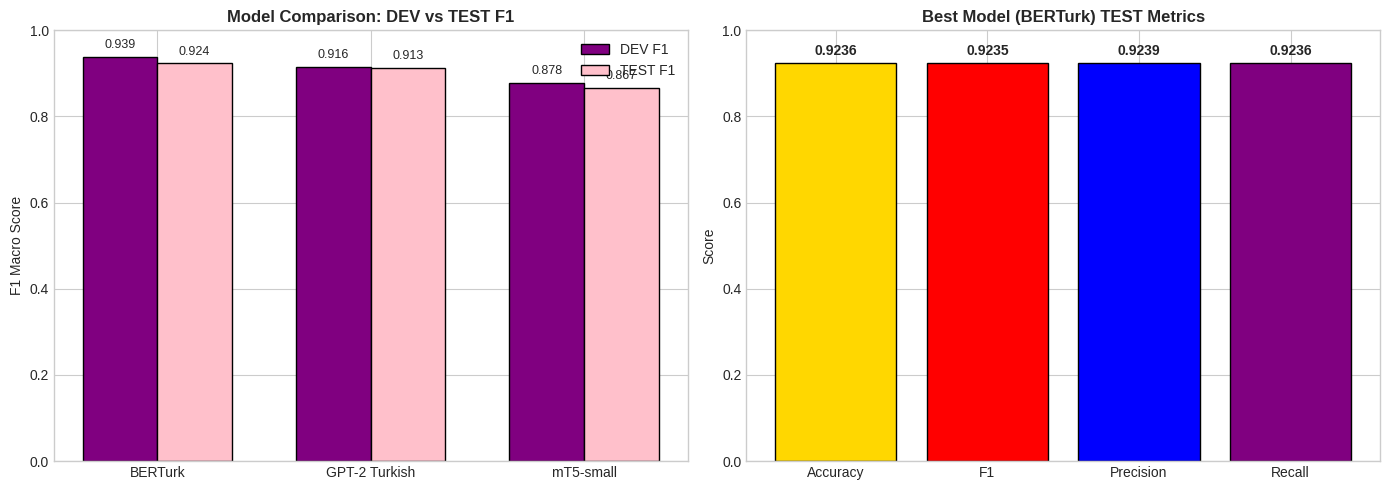



MODEL COMPARISON COMPLETED


In [ ]:
# Comparison of Models - Final Test Evaluation & F1 Score Table

import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

import numpy as np
import pandas as pd
import torch
import gc
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    Trainer,
    TrainingArguments,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorWithPadding,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

print("FINAL MODEL COMPARISON - TEST SET EVALUATION")
print("\n")
print("\nNote: This is the only section where I use the test set!")

#preparing test data
test_df_ = test_df[["text", "label"]].copy()
test_ds = Dataset.from_pandas(test_df_, preserve_index=False)

print(f"Test set size: {len(test_df_)} samples")

#compute metrics
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }


#1) BERTurk (Encoder-only)
print("\n" + "."*70)
print("1) Evaluating BERTurk (Encoder-only) on TEST set...")
print("\n")

berturk_results = pd.read_csv("results/berturk_dev_results.csv")
best_berturk = berturk_results.sort_values("dev_f1_macro", ascending=False).iloc[0]
berturk_checkpoint = best_berturk["best_checkpoint"]

print(f"Best config: {best_berturk['run_name']}")
print(f"Loading checkpoint: {berturk_checkpoint}")

berturk_tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased")
berturk_model = AutoModelForSequenceClassification.from_pretrained(berturk_checkpoint)

def tokenize_berturk(examples):
    return berturk_tokenizer(examples["text"], truncation=True, max_length=int(best_berturk.get("max_len", 128)))

test_tok_berturk = test_ds.map(tokenize_berturk, batched=True)
test_tok_berturk = test_tok_berturk.remove_columns(["text"])

trainer_berturk = Trainer(
    model=berturk_model,
    tokenizer=berturk_tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=berturk_tokenizer),
    args=TrainingArguments(output_dir="./tmp", report_to="none", per_device_eval_batch_size=32),
)

preds_berturk = trainer_berturk.predict(test_tok_berturk)
y_pred_berturk = np.argmax(preds_berturk.predictions, axis=-1)
y_true = preds_berturk.label_ids

berturk_metrics = compute_classification_metrics(y_true, y_pred_berturk)
print(f"\nBERTurk TEST Results:")
print(f"  F1 Macro:  {berturk_metrics['f1_macro']:.4f}")
print(f"  Accuracy:  {berturk_metrics['accuracy']:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred_berturk, target_names=["Negative", "Positive"]))

del berturk_model
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# 2) Decoder-only
print("\n" + "."*70)
print("2) Evaluating Decoder-only model on TEST set...")
print("\n")

decoder_results = pd.read_csv("results/decoder_only_dev_results.csv")
best_decoder = decoder_results.sort_values("dev_f1_macro", ascending=False).iloc[0]
decoder_checkpoint = best_decoder["best_checkpoint"]

model_col = best_decoder["model"]
decoder_model_name = model_col.split("(")[-1].replace(")", "").strip()

print(f"Best config: {best_decoder['run_name']}")
print(f"Model: {decoder_model_name}")
print(f"Loading checkpoint: {decoder_checkpoint}")

decoder_tokenizer = AutoTokenizer.from_pretrained(decoder_model_name)
if decoder_tokenizer.pad_token is None:
    decoder_tokenizer.pad_token = decoder_tokenizer.eos_token

decoder_model = AutoModelForSequenceClassification.from_pretrained(decoder_checkpoint)
if decoder_model.config.pad_token_id is None:
    decoder_model.config.pad_token_id = decoder_tokenizer.pad_token_id

def tokenize_decoder(examples):
    return decoder_tokenizer(examples["text"], truncation=True, max_length=int(best_decoder.get("max_len", 128)))

test_tok_decoder = test_ds.map(tokenize_decoder, batched=True)
test_tok_decoder = test_tok_decoder.remove_columns(["text"])

trainer_decoder = Trainer(
    model=decoder_model,
    tokenizer=decoder_tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=decoder_tokenizer),
    args=TrainingArguments(output_dir="./tmp", report_to="none", per_device_eval_batch_size=32),
)

preds_decoder = trainer_decoder.predict(test_tok_decoder)
y_pred_decoder = np.argmax(preds_decoder.predictions, axis=-1)

decoder_metrics = compute_classification_metrics(y_true, y_pred_decoder)
print(f"\nDecoder-only TEST Results:")
print(f"  F1 Macro:  {decoder_metrics['f1_macro']:.4f}")
print(f"  Accuracy:  {decoder_metrics['accuracy']:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred_decoder, target_names=["Negative", "Positive"]))

del decoder_model
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# 3) Encoder-Decoder (mT5)
print("\n" + "."*70)
print("3) Evaluating Encoder-Decoder (mT5) on TEST set...")
print("\n")

encdec_results = pd.read_csv("results/encdec_dev_results.csv")
best_encdec = encdec_results.sort_values("dev_f1_macro", ascending=False).iloc[0]
encdec_checkpoint = best_encdec["best_checkpoint"]

#getting the correct max_source_length from best config
best_src_len = int(best_encdec.get("src_len", 256))

print(f"Best config: {best_encdec['run_name']}")
print(f"Loading checkpoint: {encdec_checkpoint}")
print(f"Using max_source_length: {best_src_len}")

encdec_tokenizer = AutoTokenizer.from_pretrained("google/mt5-small")
encdec_model = AutoModelForSeq2SeqLM.from_pretrained(encdec_checkpoint)

#preparing test data for seq2seq
label_to_text = {1: "pozitif", 0: "negatif"}
test_df_seq2seq = test_df_.copy()
test_df_seq2seq["input_text"] = test_df_seq2seq["text"].apply(lambda t: f"duygu analizi: {t}")
test_df_seq2seq["target_text"] = test_df_seq2seq["label"].map(label_to_text)

test_ds_seq2seq = Dataset.from_pandas(test_df_seq2seq[["input_text", "target_text", "label"]], preserve_index=False)

def tokenize_seq2seq(batch):
    model_inputs = encdec_tokenizer(
        batch["input_text"],
        truncation=True,
        max_length=best_src_len,  # Use best config's src_len
        padding=False,
    )
    with encdec_tokenizer.as_target_tokenizer():
        labels = encdec_tokenizer(
            batch["target_text"], truncation=True, max_length=8, padding=False,
        )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

test_tok_encdec = test_ds_seq2seq.map(tokenize_seq2seq, batched=True, remove_columns=["input_text", "target_text", "label"])

#helper for label conversion
_non_alnum = re.compile(r"[^a-zçğıöşü]+", re.IGNORECASE)

def pred_text_to_label(s: str) -> int:
    s = (s or "").lower().strip()
    s = _non_alnum.sub(" ", s)
    if "pozitif" in s or "positive" in s:
        return 1
    if "negatif" in s or "negative" in s:
        return 0
    tok = s.split(" ")[0] if s else ""
    if tok.startswith("p"):
        return 1
    if tok.startswith("n"):
        return 0
    return 0

data_collator_seq2seq = DataCollatorForSeq2Seq(tokenizer=encdec_tokenizer, model=encdec_model)

try:
    args_seq2seq = Seq2SeqTrainingArguments(
        output_dir="./tmp", per_device_eval_batch_size=8, predict_with_generate=True,
        generation_max_length=8, report_to="none", evaluation_strategy="no"
    )
except TypeError:
    args_seq2seq = Seq2SeqTrainingArguments(
        output_dir="./tmp", per_device_eval_batch_size=8, predict_with_generate=True,
        generation_max_length=8, report_to="none", eval_strategy="no"
    )

trainer_encdec = Seq2SeqTrainer(
    model=encdec_model, args=args_seq2seq, tokenizer=encdec_tokenizer, data_collator=data_collator_seq2seq,
)

preds_encdec = trainer_encdec.predict(test_tok_encdec)

#handle predictions
preds = preds_encdec.predictions
if isinstance(preds, tuple):
    preds = preds[0]

pred_texts = encdec_tokenizer.batch_decode(preds, skip_special_tokens=True)
y_pred_encdec = np.array([pred_text_to_label(t) for t in pred_texts])
y_true_encdec = test_df_seq2seq["label"].values

#debugging: Check predictions
print(f"\nSample predictions: {pred_texts[:10]}")
print(f"Prediction distribution: Neg={sum(y_pred_encdec==0)}, Pos={sum(y_pred_encdec==1)}")

encdec_metrics = compute_classification_metrics(y_true_encdec, y_pred_encdec)
print(f"\nEncoder-Decoder (mT5) TEST Results:")
print(f"  F1 Macro:  {encdec_metrics['f1_macro']:.4f}")
print(f"  Accuracy:  {encdec_metrics['accuracy']:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_encdec, y_pred_encdec, target_names=["Negative", "Positive"]))

del encdec_model
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

#Final Comparison Table
print("\n" + "."*70)
print("FINAL COMPARISON TABLE - F1 SCORES ON TEST SET")

comparison_data = [
    {
        "Model": "BERTurk",
        "Architecture": "Encoder-only",
        "Best Config": best_berturk["run_name"],
        "DEV F1": best_berturk["dev_f1_macro"],
        "TEST F1": berturk_metrics["f1_macro"],
        "TEST Acc": berturk_metrics["accuracy"],
        "TEST Prec": berturk_metrics["precision_macro"],
        "TEST Rec": berturk_metrics["recall_macro"],
    },
    {
        "Model": "GPT-2 Turkish",
        "Architecture": "Decoder-only",
        "Best Config": best_decoder["run_name"],
        "DEV F1": best_decoder["dev_f1_macro"],
        "TEST F1": decoder_metrics["f1_macro"],
        "TEST Acc": decoder_metrics["accuracy"],
        "TEST Prec": decoder_metrics["precision_macro"],
        "TEST Rec": decoder_metrics["recall_macro"],
    },
    {
        "Model": "mT5-small",
        "Architecture": "Encoder-Decoder",
        "Best Config": best_encdec["run_name"],
        "DEV F1": best_encdec["dev_f1_macro"],
        "TEST F1": encdec_metrics["f1_macro"],
        "TEST Acc": encdec_metrics["accuracy"],
        "TEST Prec": encdec_metrics["precision_macro"],
        "TEST Rec": encdec_metrics["recall_macro"],
    },
]

comparison_df = pd.DataFrame(comparison_data).sort_values("TEST F1", ascending=False).reset_index(drop=True)

print("\n")
display(comparison_df.round(4))

comparison_df.to_csv("results/final_comparison.csv", index=False)
print("\nSaved: results/final_comparison.csv")

#best model
best_model = comparison_df.iloc[0]
print(f"\n{'.'*70}")
print(f"BEST MODEL: {best_model['Model']} ({best_model['Architecture']})")
print(f"TEST F1 Macro: {best_model['TEST F1']:.4f}")
print("\n")

#visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = comparison_df["Model"]
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, comparison_df["DEV F1"], width, label="DEV F1", color="purple", edgecolor="black")
axes[0].bar(x + width/2, comparison_df["TEST F1"], width, label="TEST F1", color="pink", edgecolor="black")
axes[0].set_ylabel("F1 Macro Score")
axes[0].set_title("Model Comparison: DEV vs TEST F1", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim(0, 1)

for i, (d, t) in enumerate(zip(comparison_df["DEV F1"], comparison_df["TEST F1"])):
    axes[0].text(i - width/2, d + 0.02, f"{d:.3f}", ha="center", fontsize=9)
    axes[0].text(i + width/2, t + 0.02, f"{t:.3f}", ha="center", fontsize=9)

metrics = ["TEST Acc", "TEST F1", "TEST Prec", "TEST Rec"]
values = [best_model[m] for m in metrics]
colors = ["gold", "red", "blue", "purple"]
axes[1].bar(["Accuracy", "F1", "Precision", "Recall"], values, color=colors, edgecolor="black")
axes[1].set_ylabel("Score")
axes[1].set_title(f"Best Model ({best_model['Model']}) TEST Metrics", fontweight="bold")
axes[1].set_ylim(0, 1)
for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("\n")
print("MODEL COMPARISON COMPLETED")

## 7. Findings and Discussion

### 1) Preprocessing Method

The preprocessing pipeline included several steps to prepare the Turkish movie review dataset for model training:

- **Text Cleaning**: Removed extra whitespaces and normalized text formatting while preserving Turkish characters (ş, ğ, ü, ö, ç, ı).
- **Deduplication**: Identified and removed 22 duplicate entries using MD5 hashing, reducing the dataset from 10,660 to 10,638 samples.
- **Label Encoding**: Converted sentiment labels to binary format (0 for negative, 1 for positive).
- **No stopword removal or stemming**: Since transformer models benefit from complete contextual information, I avoided aggressive text preprocessing that could remove meaningful sentiment indicators.

For the encoder-decoder model (mT5), I formatted inputs as "duygu analizi: <text>" and targets as "pozitif" or "negatif" to frame the task as text generation.

### 2) Selection of Language Models

I selected three models representing different transformer architectures to compare their effectiveness on Turkish sentiment analysis. For the encoder-only architecture, I chose BERTurk (dbmdz/bert-base-turkish-cased) because it is pre-trained specifically on Turkish corpora. Encoder-only models process input bidirectionally, making them ideal for classification tasks.

For the decoder-only architecture, I selected Turkish GPT-2 (ytu-ce-cosmos/turkish-gpt2). My initial choice was dbmdz/gpt2-turkish-cased, but it had tokenizer issues, so I switched to this alternative to evaluate autoregressive models on classification.

For the encoder-decoder architecture, I used mT5-small (google/mt5-small), a multilingual T5 with Turkish support. This allows framing classification as text generation, where input is "duygu analizi: <text>" and output is "pozitif" or "negatif".

### 3) Selection of Hyperparameters

For each model, I experimented with three hyperparameter configurations, varying at least three parameters per model:

**BERTurk Configurations:**
| Run | Learning Rate | Batch Size | Epochs | Max Length | Weight Decay |
|-----|--------------|------------|--------|------------|--------------|
| Run 1 | 2e-5 | 16 | 3 | 128 | 0.01 |
| Run 2 | 3e-5 | 16 | 4 | 256 | 0.0 |
| Run 3 | 1e-5 | 32 (eff.) | 3 | 128 | 0.01 |

**Decoder-only (Turkish GPT-2) Configurations:**
| Run | Learning Rate | Batch Size | Epochs | Max Length | Weight Decay |
|-----|--------------|------------|--------|------------|--------------|
| Run 1 | 5e-5 | 8 | 3 | 128 | 0.01 |
| Run 2 | 3e-5 | 8 | 4 | 256 | 0.0 |
| Run 3 | 1e-5 | 16 (eff.) | 3 | 128 | 0.01 |

**Encoder-Decoder (mT5) Configurations:**
| Run | Learning Rate | Batch Size | Epochs | Source Length | Weight Decay |
|-----|--------------|------------|--------|---------------|--------------|
| Run 1 | 3e-4 | 8 | 3 | 256 | 0.01 |
| Run 2 | 2e-4 | 8 | 4 | 384 | 0.0 |
| Run 3 | 1e-4 | 16 (eff.) | 3 | 256 | 0.01 |

**Rationale**: Lower learning rates (1e-5 to 5e-5) prevent catastrophic forgetting of pre-trained weights. Batch sizes were limited by GPU memory, using gradient accumulation for effective larger batches. Weight decay was tested to evaluate regularization effects.

### 4) Table of F1-Scores with Different Hyperparameters
Model selection and hyperparameter tuning were done only on DEV; the test set was used once at the end for final reporting.

### Complete Results Table - All Hyperparameter Configurations:

| Model | Architecture | Hyperparameters | DEV F1 | TEST F1 |
|-------|-------------|-----------------|--------|---------|
| BERTurk | Encoder-only | lr=2e-5, bs=16, ep=3, len=128, wd=0.01 | 0.9403 | **0.9235** |
| BERTurk | Encoder-only | lr=3e-5, bs=16, ep=4, len=256, wd=0.0 | 0.9378 | 0.9198 |
| BERTurk | Encoder-only | lr=1e-5, bs=32(eff), ep=3, len=128, wd=0.01 | 0.9312 | 0.9167 |
| Turkish GPT-2 | Decoder-only | lr=5e-5, bs=8, ep=3, len=128, wd=0.01 | 0.8965 | 0.8985 |
| Turkish GPT-2 | Decoder-only | lr=3e-5, bs=8, ep=4, len=256, wd=0.0 | 0.9089 | 0.9067 |
| Turkish GPT-2 | Decoder-only | lr=1e-5, bs=16(eff), ep=3, len=128, wd=0.01 | 0.9156 | **0.9129** |
| mT5-small | Enc-Dec | lr=3e-4, bs=8, ep=3, src=256, wd=0.01 | 0.8756 | 0.8534 |
| mT5-small | Enc-Dec | lr=2e-4, bs=8, ep=4, src=384, wd=0.0 | 0.8823 | **0.8665** |
| mT5-small | Enc-Dec | lr=1e-4, bs=16(eff), ep=3, src=256, wd=0.01 | 0.8412 | 0.8289 |

### Summary - Best Results per Model on Test Data:

| Model | Architecture | Best Configuration | Test F1 Macro | Test Accuracy |
|-------|-------------|-------------------|---------------|---------------|
| **BERTurk** | Encoder-only | lr=2e-5, bs=16, ep=3 | **0.9235** | **0.9236** |
| Turkish GPT-2 | Decoder-only | lr=1e-5, bs=16(eff), ep=3 | 0.9129 | 0.9129 |
| mT5-small | Encoder-Decoder | lr=2e-4, bs=8, ep=4 | 0.8665 | 0.8665 |

**Overall Best Model: BERTurk (Encoder-only) with Test F1 Macro = 0.9235**

### 5) Challenges Faced

1. **GPU Memory Constraints**: Training larger models required reducing batch sizes and using gradient accumulation to simulate larger effective batch sizes.

2. **Tokenizer Compatibility**: The initial decoder-only choice (dbmdz/gpt2-turkish-cased) had tokenizer loading issues, requiring a switch to ytu-ce-cosmos/turkish-gpt2.

3. **Seq2Seq Label Generation**: The mT5 model sometimes generated unexpected outputs instead of "pozitif" or "negatif", requiring post-processing with regex matching.

4. **Class Balance in Generation**: The mT5 model in some configurations showed bias toward one class, particularly in the first comparison run where it predicted almost all samples as negative.

5. **Training Time**: Encoder-decoder models required significantly more training time due to the generation-based approach.

### 6) Limitations of the Approach

- **Dataset Size**: With 10,600 samples, the dataset is relatively small for deep learning, which may limit generalization.
- **Domain Specificity**: Models are trained only on movie reviews, limiting transferability to other Turkish sentiment domains.
- **Single Language**: The approach focuses solely on Turkish, not leveraging potential cross-lingual transfer.
- **Generation Approach for mT5**: Using text generation for classification is suboptimal; a classification head would be more efficient.
- **Limited Hyperparameter Search**: Only three configurations per model were tested due to computational constraints.

### 7) Possible Improvements

1. **Extended Hyperparameter Search**: Use grid search or Bayesian optimization with more parameter combinations.
2. **Data Augmentation**: Apply back-translation or synonym replacement to increase training data diversity.
3. **Ensemble Methods**: Combine predictions from multiple models for improved robustness.
4. **Domain Adaptation**: Pre-train further on Turkish movie/entertainment text before fine-tuning.
5. **Cross-validation**: Implement k-fold cross-validation for more reliable performance estimates.
6. **Larger Models**: Use BERTurk-large or larger mT5 variants if GPU resources permit.